# SASRec-et előzetesen W2V téren tanítottam jelöltgenerálásra

## Tanító tábla

In [1]:
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
import faiss
import h5py
from gensim.models import Word2Vec
from tqdm.auto import tqdm
import pyarrow as pa
import pyarrow.parquet as pq
import gc

# ==========================================
# 1. ÚTVONALAK ÉS PARAMÉTEREK
# ==========================================
VAL_DATA_PATH   = "../Models/val_pids.npy"
W2V_MODEL_PATH  = "../Models/song2vec.model"
W2V_MATRIX_PATH = "../Models/hybrid_embedding_matrix_notempo.npy"
H5_FILE         = "../Dataset/spotify_dataset_compressed.h5"
WEIGHTS_PATH    = "../Models/best_sasrec_large_hard_w2v_only.weights.h5"
OUTPUT_PARQUET  = "../Models/xgboost_train_dataset_hybrid_notempo.parquet"

MAX_LEN = 50
BATCH_SIZE = 256
TOP_K = 500

# ==========================================
# 2. METAADATOK ÉS SZÓTÁR ELŐTÖLTÉSE
# ==========================================
print("📖 Word2Vec szótár és beágyazások betöltése...")
w2v_model = Word2Vec.load(W2V_MODEL_PATH)
uri_to_id = w2v_model.wv.key_to_index

embeddings = np.load(W2V_MATRIX_PATH).astype('float32')
vocab_size, D_MODEL = embeddings.shape

embeddings_norm = embeddings.copy()
faiss.normalize_L2(embeddings_norm)

print("📈 Dalok népszerűségének kiszámítása a Train halmazból...")
track_popularity = np.zeros(vocab_size, dtype=int)
train_playlists = np.load("../Models/train_pids.npy", allow_pickle=True)
for pl in train_playlists:
    for track_id in pl:
        if track_id < vocab_size:
            track_popularity[track_id] += 1

track_global_entropy = np.full(vocab_size, np.nan, dtype=np.float32)
track_max_local_entropy = np.full(vocab_size, np.nan, dtype=np.float32)
track_is_cnn = np.zeros(vocab_size, dtype=int)

print("🧮 HDF5 metaadatok beolvasása...")
with h5py.File(H5_FILE, "r") as hf:
    track_uris_hdf5 = hf["ml/track_uri"][:]
    entropy_global_data = hf["features/markov_entropy_global"][:]
    entropy_local_data = hf["features/markov_entropy_local"][:]

    if isinstance(track_uris_hdf5[0], bytes):
        track_uris_hdf5 = [uri.decode('utf-8') for uri in track_uris_hdf5]

    for hdf5_idx, uri in enumerate(tqdm(track_uris_hdf5, desc="Mapping")):
        if uri in uri_to_id:
            sasrec_id = uri_to_id[uri]
            if sasrec_id < vocab_size:
                track_global_entropy[sasrec_id] = entropy_global_data[hdf5_idx][0]
                track_max_local_entropy[sasrec_id] = np.max(entropy_local_data[hdf5_idx])
                track_is_cnn[sasrec_id] = 1

print(f"❄️ Cold Start szimulálva: {(track_is_cnn == 1).sum():,} dal népszerűsége lenullázva.")
track_popularity[track_is_cnn == 1] = 0

# ==========================================
# 3. SASREC MODELL (INFERENCIA VERZIÓ)
# ==========================================
print("🏗️ SASRec Modell inicializálása...")
def create_inference_model(vocab_size, init_weights):
    seq_inputs = layers.Input(shape=(MAX_LEN,), name="seq_inputs")
    item_embedding = layers.Embedding(
        vocab_size, D_MODEL, mask_zero=True,
        embeddings_initializer=tf.keras.initializers.Constant(init_weights),
        trainable=True, name="w2v_embedding"
    )
    pos_embedding = layers.Embedding(MAX_LEN, D_MODEL, name="pos_embedding")
    x = item_embedding(seq_inputs)
    x += pos_embedding(tf.range(MAX_LEN)[tf.newaxis, :])
    for _ in range(3):
        attn = layers.MultiHeadAttention(num_heads=8, key_dim=D_MODEL//8)(x, x, use_causal_mask=True)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(attn))
        ffn = layers.Dense(D_MODEL * 4, activation='relu')(x)
        ffn = layers.Dense(D_MODEL)(ffn)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(ffn))
    seq_states = layers.Dense(D_MODEL, name="final_projection")(x)
    return tf.keras.Model(inputs=seq_inputs, outputs=seq_states)

inference_model = create_inference_model(vocab_size, embeddings)
inference_model.load_weights(WEIGHTS_PATH)

print("🔍 FAISS Index építése...")
updated_embeddings = inference_model.get_layer("w2v_embedding").get_weights()[0]
faiss_embeddings = updated_embeddings.copy().astype('float32')
faiss.normalize_L2(faiss_embeddings)
index = faiss.IndexFlatIP(D_MODEL)
index.add(faiss_embeddings)

# ==========================================
# 4. KÖTEGELT TÁBLÁZATGENERÁLÁS (STREAMINGGEL)
# ==========================================
print("🚀 Táblázat generálása és folyamatos lemezre írása...")
val_playlists = np.load(VAL_DATA_PATH, allow_pickle=True)
val_playlists = np.array([[t for t in pl if t != 0] for pl in val_playlists], dtype=object)

dataset_rows = []
global_playlist_id = 0
writer = None

for i in tqdm(range(0, len(val_playlists), BATCH_SIZE), desc="SASRec Predikciók"):
    batch_lists = val_playlists[i : i + BATCH_SIZE]
    batch_padded, targets, valid_contexts = [], [], []

    for pl in batch_lists:
        if len(pl) < 2: continue
        targets.append(pl[-1])
        context = pl[:-1]
        valid_contexts.append(context)
        input_seq = context[-MAX_LEN:]
        batch_padded.append([0] * (MAX_LEN - len(input_seq)) + list(input_seq))

    if not batch_padded: continue

    pred_vectors = inference_model.predict_on_batch(np.array(batch_padded))
    target_pred_vectors = pred_vectors[:, -1, :].astype('float32')
    faiss.normalize_L2(target_pred_vectors)
    raw_scores, raw_indices = index.search(target_pred_vectors, TOP_K + MAX_LEN)

    for b_idx in range(len(valid_contexts)):
        context = valid_contexts[b_idx]
        actual_target = targets[b_idx]
        last_track_vec = embeddings_norm[context[-1]]

        playlist_mean_vec = np.mean(embeddings_norm[context], axis=0)
        playlist_mean_vec /= (np.linalg.norm(playlist_mean_vec) + 1e-8)

        context_pops = [track_popularity[t] for t in context]
        playlist_pop_mean = float(np.mean(context_pops))
        playlist_pop_std = float(np.std(context_pops))

        context_entropies = [track_global_entropy[t] for t in context
                             if not np.isnan(track_global_entropy[t])]
        playlist_entropy_mean = float(np.mean(context_entropies)) \
                                if len(context_entropies) > 0 else 0.0

        context_local_entropies = [track_max_local_entropy[t] for t in context
                                   if not np.isnan(track_max_local_entropy[t])]
        playlist_local_entropy_mean = float(np.mean(context_local_entropies)) \
                                      if len(context_local_entropies) > 0 else 0.0

        # ← ÚJ: Playlist szintű számítások amik minden jelöltre ugyanazok
        recent_3 = context[-3:]
        recent_3_vecs = embeddings_norm[recent_3]  # (3, D) mátrix

        # Playlist dalok népszerűsége tömbként — Pop_Rank_in_Context-hez
        context_pops_arr = np.array(context_pops)

        # Max hasonlóság a kontextusban — előre kiszámolva
        # (context_size, D) @ (D,) → (context_size,) dot productok
        context_vecs = embeddings_norm[list(context)]  # (N, D)

        pos_samples, neg_samples = [], []
        current_rank = 1

        for score, cand_id in zip(raw_scores[b_idx], raw_indices[b_idx]):
            if cand_id in context or cand_id == 0: continue
            if len(pos_samples) + len(neg_samples) >= TOP_K: break

            is_target = 1 if cand_id == actual_target else 0
            cand_vec = embeddings_norm[cand_id]
            cand_pop = track_popularity[cand_id]
            cand_entropy = track_global_entropy[cand_id]
            cand_local_entropy = track_max_local_entropy[cand_id]

            pop_ratio = cand_pop / (playlist_pop_mean + 1.0)
            entropy_diff = abs(cand_entropy - playlist_entropy_mean) \
                           if not np.isnan(cand_entropy) else -1.0
            local_entropy_diff = abs(cand_local_entropy - playlist_local_entropy_mean) \
                                 if not np.isnan(cand_local_entropy) else -1.0

            # ← ÚJ FEATURE-ÖK
            # 1. Utolsó 3 dal átlagos hasonlósága
            sim_to_recent_3 = float(np.mean(recent_3_vecs @ cand_vec))

            # 2. Leghasonlóbb dal a kontextusban
            max_sim_in_context = float(np.max(context_vecs @ cand_vec))

            # 3. Hány kontextus dal népszerűbb a jelöltnél (arány)
            pop_rank_in_context = float(np.mean(context_pops_arr > cand_pop))

            row = {
                "Playlist_ID": global_playlist_id,
                "Candidate_ID": cand_id,
                "Playlist_Length": len(context),
                "SASRec_Rank": current_rank,
                "SASRec_Score": float(score),
                "Sim_to_Last": float(np.dot(last_track_vec, cand_vec)),
                "Sim_to_Mean": float(np.dot(playlist_mean_vec, cand_vec)),
                "Sim_to_Recent_3": sim_to_recent_3,       # ← ÚJ
                "Max_Sim_in_Context": max_sim_in_context, # ← ÚJ
                "Track_Popularity": cand_pop,
                "Global_Entropy": cand_entropy,
                "Max_Local_Entropy": cand_local_entropy,
                "Playlist_Pop_Mean": playlist_pop_mean,
                "Playlist_Pop_Std": playlist_pop_std,
                "Candidate_Pop_Ratio": float(pop_ratio),
                "Pop_Rank_in_Context": pop_rank_in_context, # ← ÚJ
                "Entropy_Diff": float(entropy_diff),
                "Local_Entropy_Diff": float(local_entropy_diff),
                "Label": is_target
            }

            if is_target:
                pos_samples.append(row)
            else:
                neg_samples.append(row)
            current_rank += 1

        dataset_rows.extend(pos_samples)
        dataset_rows.extend(neg_samples)
        global_playlist_id += 1

    # --- FLUSH ---
    if len(dataset_rows) >= 500000:
        df_chunk = pd.DataFrame(dataset_rows)
        table = pa.Table.from_pandas(df_chunk)
        if writer is None:
            writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
        writer.write_table(table)
        dataset_rows.clear()
        del df_chunk, table
        gc.collect()

# ==========================================
# 5. MARADÉK KIÍRÁSA ÉS FÁJL LEZÁRÁSA
# ==========================================
print("💾 Maradék adatok mentése és fájl lezárása...")
if len(dataset_rows) > 0:
    df_chunk = pd.DataFrame(dataset_rows)
    table = pa.Table.from_pandas(df_chunk)
    if writer is None:
        writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
    writer.write_table(table)

if writer is not None:
    writer.close()

# ==========================================
# 6. SZŰRÉS
# ==========================================
print("🧹 Pozitív nélküli listák szűrése...")
df = pd.read_parquet(OUTPUT_PARQUET)
lists_with_pos = df[df['Label'] == 1]['Playlist_ID'].unique()
df_filtered = df[df['Playlist_ID'].isin(lists_with_pos)].reset_index(drop=True)
df_filtered.to_parquet(OUTPUT_PARQUET.replace('.parquet', '_filtered.parquet'), index=False)

print(f"🎉 KÉSZ! Generált sorok: {len(df):,} → Szűrt sorok: {len(df_filtered):,}")
del df, df_filtered
gc.collect()

📖 Word2Vec szótár és beágyazások betöltése...
📈 Dalok népszerűségének kiszámítása a Train halmazból...
🧮 HDF5 metaadatok beolvasása...


Mapping:   0%|          | 0/27052 [00:00<?, ?it/s]

❄️ Cold Start szimulálva: 25,511 dal népszerűsége lenullázva.
🏗️ SASRec Modell inicializálása...
🔍 FAISS Index építése...
🚀 Táblázat generálása és folyamatos lemezre írása...


SASRec Predikciók:   0%|          | 0/388 [00:00<?, ?it/s]

💾 Maradék adatok mentése és fájl lezárása...
🧹 Pozitív nélküli listák szűrése...
🎉 KÉSZ! Generált sorok: 49,340,790 → Szűrt sorok: 22,631,195


19

## Tanítás

📂 Parquet fájl betöltése...
✅ Tanító halmaz: 21,478,154 sor
✅ Validációs halmaz: 1,153,041 sor

🚀 XGBoost tanítás indítása...
[0]	validation_0-ndcg@10:0.14254	validation_0-map@10:0.10859
[50]	validation_0-ndcg@10:0.14285	validation_0-map@10:0.11099
[100]	validation_0-ndcg@10:0.14634	validation_0-map@10:0.11362
[150]	validation_0-ndcg@10:0.14524	validation_0-map@10:0.11295
[200]	validation_0-ndcg@10:0.14640	validation_0-map@10:0.11402
[250]	validation_0-ndcg@10:0.14766	validation_0-map@10:0.11480
[300]	validation_0-ndcg@10:0.14651	validation_0-map@10:0.11366
[350]	validation_0-ndcg@10:0.14702	validation_0-map@10:0.11485
[400]	validation_0-ndcg@10:0.14605	validation_0-map@10:0.11393
[444]	validation_0-ndcg@10:0.14504	validation_0-map@10:0.11325

💾 Modell sikeresen elmentve!

📊 Jellemzők fontosságának (Feature Importance) kirajzolása...


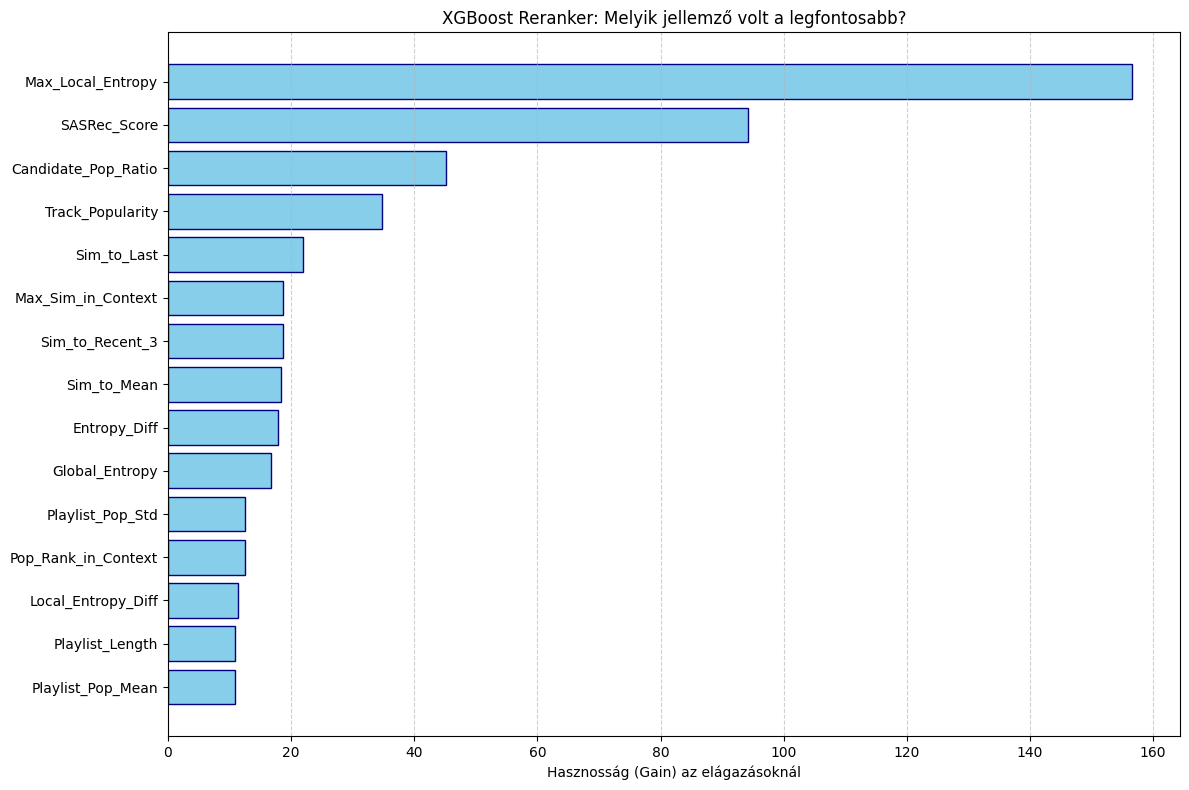


📈 Tanulási görbe...


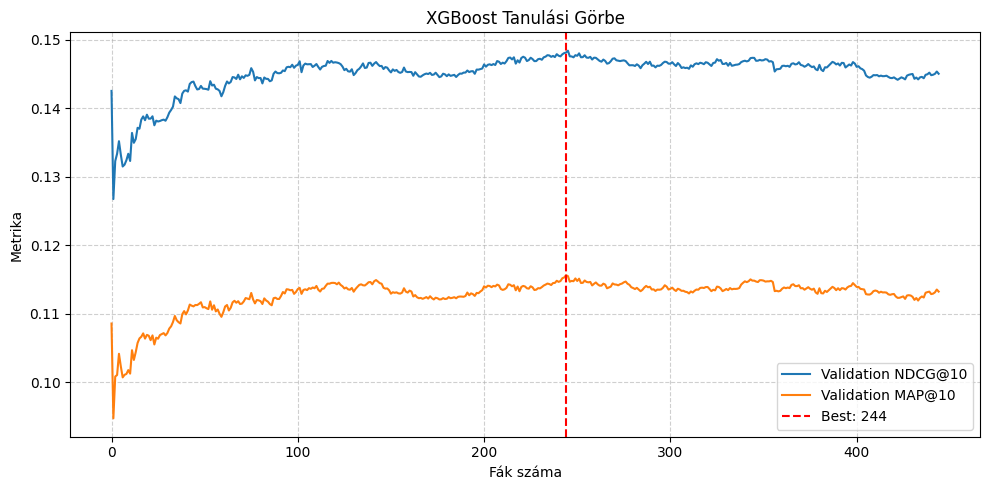

🏆 Legjobb iteráció: 244
🏆 Legjobb NDCG@10: 0.1484


In [2]:
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

# ==========================================
# 1. ADATBETÖLTÉS ÉS RENDEZÉS
# ==========================================
print("📂 Parquet fájl betöltése...")
df = pd.read_parquet("../Models/xgboost_train_dataset_hybrid_notempo_filtered.parquet")  # ← filtered
df = df.sort_values("Playlist_ID").reset_index(drop=True)

# Listán belüli shuffle — pozitív ne legyen mindig elöl
shuffled_parts = []
for pid, group in df.groupby("Playlist_ID"):
    shuffled_parts.append(group.sample(frac=1, random_state=42))
df = pd.concat(shuffled_parts).reset_index(drop=True)

# ==========================================
# 2. JELLEMZŐK DEFINIÁLÁSA
# ==========================================
features = [
    'Playlist_Length',
    #'SASRec_Rank',
    'SASRec_Score',
    'Sim_to_Last',
    'Sim_to_Mean',
    'Sim_to_Recent_3',       # ← ÚJ
    'Max_Sim_in_Context',    # ← ÚJ
    'Track_Popularity',
    'Global_Entropy',
    'Max_Local_Entropy',
    'Playlist_Pop_Mean',
    'Playlist_Pop_Std',
    'Candidate_Pop_Ratio',
    'Pop_Rank_in_Context',   # ← ÚJ
    'Entropy_Diff',
    'Local_Entropy_Diff'
]

X = df[features]
y = df['Label']
groups = df['Playlist_ID']

# ==========================================
# 3. TRAIN-VAL SPLIT
# ==========================================
total_playlists = groups.max()
train_idx = groups < (total_playlists - 5000)

X_train, y_train, qid_train = X[train_idx], y[train_idx], groups[train_idx]
X_val, y_val, qid_val = X[~train_idx], y[~train_idx], groups[~train_idx]

print(f"✅ Tanító halmaz: {len(X_train):,} sor")
print(f"✅ Validációs halmaz: {len(X_val):,} sor")

# ==========================================
# 4. MODELL DEFINÍCIÓ ÉS TANÍTÁS
# ==========================================
print("\n🚀 XGBoost tanítás indítása...")

ranker = xgb.XGBRanker(
    objective='rank:ndcg',
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    tree_method='hist',
    random_state=42,
    eval_metric=['ndcg@10', 'map@10'],
    early_stopping_rounds=200
)

ranker.fit(
    X_train, y_train,
    qid=qid_train,
    eval_set=[(X_val, y_val)],
    eval_qid=[qid_val],
    verbose=50
)

# ==========================================
# 5. MENTÉS ÉS VIZUALIZÁCIÓ
# ==========================================
ranker.save_model("../Models/xgboost_reranker_final_hybrid_notempo.json")
print("\n💾 Modell sikeresen elmentve!")

print("\n📊 Jellemzők fontosságának (Feature Importance) kirajzolása...")
importance = ranker.get_booster().get_score(importance_type='gain')
sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)
labels, values = zip(*sorted_importance)

plt.figure(figsize=(12, 8))
plt.barh(labels[::-1], values[::-1], color='skyblue', edgecolor='navy')
plt.xlabel("Hasznosság (Gain) az elágazásoknál")
plt.title("XGBoost Reranker: Melyik jellemző volt a legfontosabb?")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\n📈 Tanulási görbe...")
results = ranker.evals_result()
plt.figure(figsize=(10, 5))
plt.plot(results['validation_0']['ndcg@10'], label='Validation NDCG@10')
plt.plot(results['validation_0']['map@10'],  label='Validation MAP@10')
plt.axvline(x=ranker.best_iteration, color='red', linestyle='--',
            label=f'Best: {ranker.best_iteration}')
plt.legend()
plt.title('XGBoost Tanulási Görbe')
plt.xlabel('Fák száma')
plt.ylabel('Metrika')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"🏆 Legjobb iteráció: {ranker.best_iteration}")
print(f"🏆 Legjobb NDCG@10: {max(results['validation_0']['ndcg@10']):.4f}")

## Teszt tábla

In [3]:
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
import faiss
import h5py
from gensim.models import Word2Vec
from tqdm.auto import tqdm
import pyarrow as pa
import pyarrow.parquet as pq
import gc

# ==========================================
# 1. ÚTVONALAK ÉS PARAMÉTEREK
# ==========================================
VAL_DATA_PATH   = "../Models/test_pids.npy"
W2V_MODEL_PATH  = "../Models/song2vec.model"
W2V_MATRIX_PATH = "../Models/hybrid_embedding_matrix_notempo.npy"
H5_FILE         = "../Dataset/spotify_dataset_compressed.h5"
WEIGHTS_PATH    = "../Models/best_sasrec_large_hard_w2v_only.weights.h5"
OUTPUT_PARQUET  = "../Models/xgboost_test_dataset_hybrid_notempo.parquet"

MAX_LEN = 50
BATCH_SIZE = 256
TOP_K = 500

# ==========================================
# 2. METAADATOK ÉS SZÓTÁR ELŐTÖLTÉSE
# ==========================================
print("📖 Word2Vec szótár és beágyazások betöltése...")
w2v_model = Word2Vec.load(W2V_MODEL_PATH)
uri_to_id = w2v_model.wv.key_to_index

embeddings = np.load(W2V_MATRIX_PATH).astype('float32')
vocab_size, D_MODEL = embeddings.shape

embeddings_norm = embeddings.copy()
faiss.normalize_L2(embeddings_norm)

print("📈 Dalok népszerűségének kiszámítása a Train halmazból...")
track_popularity = np.zeros(vocab_size, dtype=int)
train_playlists = np.load("../Models/train_pids.npy", allow_pickle=True)
for pl in train_playlists:
    for track_id in pl:
        if track_id < vocab_size:
            track_popularity[track_id] += 1

track_global_entropy = np.full(vocab_size, np.nan, dtype=np.float32)
track_max_local_entropy = np.full(vocab_size, np.nan, dtype=np.float32)
track_is_cnn = np.zeros(vocab_size, dtype=int)

print("🧮 HDF5 metaadatok beolvasása...")
with h5py.File(H5_FILE, "r") as hf:
    track_uris_hdf5 = hf["ml/track_uri"][:]
    entropy_global_data = hf["features/markov_entropy_global"][:]
    entropy_local_data = hf["features/markov_entropy_local"][:]

    if isinstance(track_uris_hdf5[0], bytes):
        track_uris_hdf5 = [uri.decode('utf-8') for uri in track_uris_hdf5]

    for hdf5_idx, uri in enumerate(tqdm(track_uris_hdf5, desc="Mapping")):
        if uri in uri_to_id:
            sasrec_id = uri_to_id[uri]
            if sasrec_id < vocab_size:
                track_global_entropy[sasrec_id] = entropy_global_data[hdf5_idx][0]
                track_max_local_entropy[sasrec_id] = np.max(entropy_local_data[hdf5_idx])
                track_is_cnn[sasrec_id] = 1

print(f"❄️ Cold Start szimulálva: {(track_is_cnn == 1).sum():,} dal népszerűsége lenullázva.")
track_popularity[track_is_cnn == 1] = 0

# ==========================================
# 3. SASREC MODELL (INFERENCIA VERZIÓ)
# ==========================================
print("🏗️ SASRec Modell inicializálása...")
def create_inference_model(vocab_size, init_weights):
    seq_inputs = layers.Input(shape=(MAX_LEN,), name="seq_inputs")
    item_embedding = layers.Embedding(
        vocab_size, D_MODEL, mask_zero=True,
        embeddings_initializer=tf.keras.initializers.Constant(init_weights),
        trainable=True, name="w2v_embedding"
    )
    pos_embedding = layers.Embedding(MAX_LEN, D_MODEL, name="pos_embedding")
    x = item_embedding(seq_inputs)
    x += pos_embedding(tf.range(MAX_LEN)[tf.newaxis, :])
    for _ in range(3):
        attn = layers.MultiHeadAttention(num_heads=8, key_dim=D_MODEL//8)(x, x, use_causal_mask=True)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(attn))
        ffn = layers.Dense(D_MODEL * 4, activation='relu')(x)
        ffn = layers.Dense(D_MODEL)(ffn)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(ffn))
    seq_states = layers.Dense(D_MODEL, name="final_projection")(x)
    return tf.keras.Model(inputs=seq_inputs, outputs=seq_states)

inference_model = create_inference_model(vocab_size, embeddings)
inference_model.load_weights(WEIGHTS_PATH)

print("🔍 FAISS Index építése...")
updated_embeddings = inference_model.get_layer("w2v_embedding").get_weights()[0]
faiss_embeddings = updated_embeddings.copy().astype('float32')
faiss.normalize_L2(faiss_embeddings)
index = faiss.IndexFlatIP(D_MODEL)
index.add(faiss_embeddings)

# ==========================================
# 4. KÖTEGELT TÁBLÁZATGENERÁLÁS (STREAMINGGEL)
# ==========================================
print("🚀 Táblázat generálása és folyamatos lemezre írása...")
val_playlists = np.load(VAL_DATA_PATH, allow_pickle=True)
val_playlists = np.array([[t for t in pl if t != 0] for pl in val_playlists], dtype=object)

dataset_rows = []
global_playlist_id = 0
writer = None

for i in tqdm(range(0, len(val_playlists), BATCH_SIZE), desc="SASRec Predikciók"):
    batch_lists = val_playlists[i : i + BATCH_SIZE]
    batch_padded, targets, valid_contexts = [], [], []

    for pl in batch_lists:
        if len(pl) < 2: continue
        targets.append(pl[-1])
        context = pl[:-1]
        valid_contexts.append(context)
        input_seq = context[-MAX_LEN:]
        batch_padded.append([0] * (MAX_LEN - len(input_seq)) + list(input_seq))

    if not batch_padded: continue

    pred_vectors = inference_model.predict_on_batch(np.array(batch_padded))
    target_pred_vectors = pred_vectors[:, -1, :].astype('float32')
    faiss.normalize_L2(target_pred_vectors)
    raw_scores, raw_indices = index.search(target_pred_vectors, TOP_K + MAX_LEN)

    for b_idx in range(len(valid_contexts)):
        context = valid_contexts[b_idx]
        actual_target = targets[b_idx]
        last_track_vec = embeddings_norm[context[-1]]

        playlist_mean_vec = np.mean(embeddings_norm[context], axis=0)
        playlist_mean_vec /= (np.linalg.norm(playlist_mean_vec) + 1e-8)

        context_pops = [track_popularity[t] for t in context]
        playlist_pop_mean = float(np.mean(context_pops))
        playlist_pop_std = float(np.std(context_pops))

        context_entropies = [track_global_entropy[t] for t in context
                             if not np.isnan(track_global_entropy[t])]
        playlist_entropy_mean = float(np.mean(context_entropies)) \
                                if len(context_entropies) > 0 else 0.0

        context_local_entropies = [track_max_local_entropy[t] for t in context
                                   if not np.isnan(track_max_local_entropy[t])]
        playlist_local_entropy_mean = float(np.mean(context_local_entropies)) \
                                      if len(context_local_entropies) > 0 else 0.0

        # ← ÚJ: Playlist szintű számítások amik minden jelöltre ugyanazok
        recent_3 = context[-3:]
        recent_3_vecs = embeddings_norm[recent_3]  # (3, D) mátrix

        # Playlist dalok népszerűsége tömbként — Pop_Rank_in_Context-hez
        context_pops_arr = np.array(context_pops)

        # Max hasonlóság a kontextusban — előre kiszámolva
        # (context_size, D) @ (D,) → (context_size,) dot productok
        context_vecs = embeddings_norm[list(context)]  # (N, D)

        pos_samples, neg_samples = [], []
        current_rank = 1

        for score, cand_id in zip(raw_scores[b_idx], raw_indices[b_idx]):
            if cand_id in context or cand_id == 0: continue
            if len(pos_samples) + len(neg_samples) >= TOP_K: break

            is_target = 1 if cand_id == actual_target else 0
            cand_vec = embeddings_norm[cand_id]
            cand_pop = track_popularity[cand_id]
            cand_entropy = track_global_entropy[cand_id]
            cand_local_entropy = track_max_local_entropy[cand_id]

            pop_ratio = cand_pop / (playlist_pop_mean + 1.0)
            entropy_diff = abs(cand_entropy - playlist_entropy_mean) \
                           if not np.isnan(cand_entropy) else -1.0
            local_entropy_diff = abs(cand_local_entropy - playlist_local_entropy_mean) \
                                 if not np.isnan(cand_local_entropy) else -1.0

            # ← ÚJ FEATURE-ÖK
            # 1. Utolsó 3 dal átlagos hasonlósága
            sim_to_recent_3 = float(np.mean(recent_3_vecs @ cand_vec))

            # 2. Leghasonlóbb dal a kontextusban
            max_sim_in_context = float(np.max(context_vecs @ cand_vec))

            # 3. Hány kontextus dal népszerűbb a jelöltnél (arány)
            pop_rank_in_context = float(np.mean(context_pops_arr > cand_pop))

            row = {
                "Playlist_ID": global_playlist_id,
                "Candidate_ID": cand_id,
                "Playlist_Length": len(context),
                "SASRec_Rank": current_rank,
                "SASRec_Score": float(score),
                "Sim_to_Last": float(np.dot(last_track_vec, cand_vec)),
                "Sim_to_Mean": float(np.dot(playlist_mean_vec, cand_vec)),
                "Sim_to_Recent_3": sim_to_recent_3,       # ← ÚJ
                "Max_Sim_in_Context": max_sim_in_context, # ← ÚJ
                "Track_Popularity": cand_pop,
                "Global_Entropy": cand_entropy,
                "Max_Local_Entropy": cand_local_entropy,
                "Playlist_Pop_Mean": playlist_pop_mean,
                "Playlist_Pop_Std": playlist_pop_std,
                "Candidate_Pop_Ratio": float(pop_ratio),
                "Pop_Rank_in_Context": pop_rank_in_context, # ← ÚJ
                "Entropy_Diff": float(entropy_diff),
                "Local_Entropy_Diff": float(local_entropy_diff),
                "Label": is_target
            }

            if is_target:
                pos_samples.append(row)
            else:
                neg_samples.append(row)
            current_rank += 1

        dataset_rows.extend(pos_samples)
        dataset_rows.extend(neg_samples)
        global_playlist_id += 1

    # --- FLUSH ---
    if len(dataset_rows) >= 500000:
        df_chunk = pd.DataFrame(dataset_rows)
        table = pa.Table.from_pandas(df_chunk)
        if writer is None:
            writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
        writer.write_table(table)
        dataset_rows.clear()
        del df_chunk, table
        gc.collect()

# ==========================================
# 5. MARADÉK KIÍRÁSA ÉS FÁJL LEZÁRÁSA
# ==========================================
print("💾 Maradék adatok mentése és fájl lezárása...")
if len(dataset_rows) > 0:
    df_chunk = pd.DataFrame(dataset_rows)
    table = pa.Table.from_pandas(df_chunk)
    if writer is None:
        writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
    writer.write_table(table)

if writer is not None:
    writer.close()

# ==========================================
# 6. SZŰRÉS
# ==========================================
print("🧹 Pozitív nélküli listák szűrése...")
df = pd.read_parquet(OUTPUT_PARQUET)
lists_with_pos = df[df['Label'] == 1]['Playlist_ID'].unique()
df_filtered = df[df['Playlist_ID'].isin(lists_with_pos)].reset_index(drop=True)
df_filtered.to_parquet(OUTPUT_PARQUET.replace('.parquet', '_filtered.parquet'), index=False)

print(f"🎉 KÉSZ! Generált sorok: {len(df):,} → Szűrt sorok: {len(df_filtered):,}")
del df, df_filtered
gc.collect()

📖 Word2Vec szótár és beágyazások betöltése...
📈 Dalok népszerűségének kiszámítása a Train halmazból...
🧮 HDF5 metaadatok beolvasása...


Mapping:   0%|          | 0/27052 [00:00<?, ?it/s]

❄️ Cold Start szimulálva: 25,511 dal népszerűsége lenullázva.
🏗️ SASRec Modell inicializálása...
🔍 FAISS Index építése...
🚀 Táblázat generálása és folyamatos lemezre írása...


SASRec Predikciók:   0%|          | 0/388 [00:00<?, ?it/s]

💾 Maradék adatok mentése és fájl lezárása...
🧹 Pozitív nélküli listák szűrése...
🎉 KÉSZ! Generált sorok: 49,354,593 → Szűrt sorok: 22,512,894


19

## Kiértékelés

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb

df_test = pd.read_parquet("../Models/xgboost_test_dataset_hybrid_notempo.parquet")

features = [
    'Playlist_Length',
    'SASRec_Score',
    'Sim_to_Last',
    'Sim_to_Mean',
    'Sim_to_Recent_3',       # ← ÚJ
    'Max_Sim_in_Context',    # ← ÚJ
    'Track_Popularity',
    'Global_Entropy',
    'Max_Local_Entropy',
    'Playlist_Pop_Mean',
    'Playlist_Pop_Std',
    'Candidate_Pop_Ratio',
    'Pop_Rank_in_Context',   # ← ÚJ
    'Entropy_Diff',
    'Local_Entropy_Diff'
]

ranker = xgb.XGBRanker()
ranker.load_model("../Models/xgboost_reranker_final_hybrid.json")

df_test['XGB_Score'] = ranker.predict(df_test[features])
df_test['XGB_Rank'] = df_test.groupby('Playlist_ID')['XGB_Score'].rank(
    ascending=False, method='first'
).astype(int)

def calculate_metrics(df, rank_col, k_list):
    hits_df = df[df['Label'] == 1].copy()
    pos_ranks = hits_df[rank_col].values
    total_queries = df['Playlist_ID'].nunique()
    
    results = []
    for k in k_list:
        hr    = (pos_ranks <= k).sum() / total_queries
        ndcg  = np.sum([1/np.log2(r+1) if r <= k else 0 for r in pos_ranks]) / total_queries
        map_k = np.sum([1/r if r <= k else 0 for r in pos_ranks]) / total_queries
        results.append({'k': k, 'HR': hr, 'NDCG': ndcg, 'MAP': map_k})
    
    def get_click(r):
        if r > 500 or pd.isna(r): return 51
        return (int(r) - 1) // 10
    avg_clicks = hits_df[rank_col].apply(get_click).sum()
    missing = total_queries - len(hits_df)
    avg_clicks = (avg_clicks + missing * 51) / total_queries
    
    return pd.DataFrame(results), avg_clicks

K_VALUES = [1, 5, 10, 20, 50, 100, 200, 500]
sas_m, sas_c = calculate_metrics(df_test, 'SASRec_Rank', K_VALUES)
xgb_m, xgb_c = calculate_metrics(df_test, 'XGB_Rank',   K_VALUES)

summary = sas_m.set_index('k').join(xgb_m.set_index('k'), lsuffix='_SAS', rsuffix='_XGB')
for m in ['HR', 'NDCG', 'MAP']:
    summary[f'{m}_imp%'] = (summary[f'{m}_XGB'] - summary[f'{m}_SAS']) / summary[f'{m}_SAS'] * 100

print("\n" + "="*70)
print("🏆 EREDMÉNYEK")
print("="*70)
pd.options.display.float_format = '{:.4f}'.format
cols = [c for m in ['HR','NDCG','MAP'] for c in [f'{m}_SAS', f'{m}_XGB', f'{m}_imp%']]
print(summary[cols].T.to_string())
print(f"\n🖱️ Clicks SASRec:  {sas_c:.4f}")
print(f"🖱️ Clicks XGBoost: {xgb_c:.4f}")
print(f"🚀 Clicks javulás: {(xgb_c - sas_c)/sas_c*100:.2f}%")


🏆 EREDMÉNYEK
k             1       5       10      20      50      100     200     500
HR_SAS     0.0222  0.0628  0.0936  0.1327  0.2006  0.2671  0.3446  0.4568
HR_XGB     0.0309  0.0791  0.1162  0.1636  0.2435  0.3174  0.3953  0.4568
HR_imp%   39.4270 25.9794 24.1379 23.2738 21.3966 18.7960 14.7188  0.0000
NDCG_SAS   0.0222  0.0427  0.0526  0.0625  0.0759  0.0866  0.0974  0.1110
NDCG_XGB   0.0309  0.0552  0.0672  0.0791  0.0949  0.1069  0.1178  0.1253
NDCG_imp% 39.4270 29.3578 27.7658 26.6874 25.1184 23.3710 20.8849 12.9526
MAP_SAS    0.0222  0.0361  0.0402  0.0428  0.0450  0.0459  0.0465  0.0468
MAP_XGB    0.0309  0.0474  0.0523  0.0556  0.0581  0.0591  0.0597  0.0599
MAP_imp%  39.4270 31.2919 30.3195 29.6972 29.1471 28.7832 28.4681 27.9368

🖱️ Clicks SASRec:  33.0997
🖱️ Clicks XGBoost: 31.3340
🚀 Clicks javulás: -5.33%


# Multi target

In [1]:
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
import faiss
import h5py
from gensim.models import Word2Vec
from tqdm.auto import tqdm
import pyarrow as pa
import pyarrow.parquet as pq
import gc

# ==========================================
# 1. ÚTVONALAK ÉS PARAMÉTEREK
# ==========================================
VAL_DATA_PATH   = "../Models/val_pids.npy"
W2V_MODEL_PATH  = "../Models/song2vec.model"
W2V_MATRIX_PATH = "../Models/hybrid_embedding_matrix_notempo.npy"
H5_FILE         = "../Dataset/spotify_dataset_compressed.h5"
WEIGHTS_PATH    = "../Models/best_sasrec_large_hard_w2v_only.weights.h5"
OUTPUT_PARQUET  = "../Models/xgboost_train_dataset_hybrid_multi_notempo_variable.parquet"

MAX_LEN    = 50
BATCH_SIZE = 256
TOP_K      = 1000
MIN_GIVEN  = 1
MAX_GIVEN  = 10

# ==========================================
# 2. METAADATOK ÉS SZÓTÁR ELŐTÖLTÉSE
# ==========================================
print("📖 Word2Vec szótár és beágyazások betöltése...")
w2v_model = Word2Vec.load(W2V_MODEL_PATH)
uri_to_id = w2v_model.wv.key_to_index

embeddings = np.load(W2V_MATRIX_PATH).astype('float32')
vocab_size, D_MODEL = embeddings.shape

embeddings_norm = embeddings.copy()
faiss.normalize_L2(embeddings_norm)

print("📈 Dalok népszerűségének kiszámítása...")
track_popularity = np.zeros(vocab_size, dtype=int)
train_playlists = np.load("../Models/train_pids.npy", allow_pickle=True)
for pl in train_playlists[::10]:  # ← minden 10. lista
    for track_id in pl:
        if track_id < vocab_size:
            track_popularity[track_id] += 1

track_global_entropy = np.full(vocab_size, np.nan, dtype=np.float32)
track_max_local_entropy = np.full(vocab_size, np.nan, dtype=np.float32)
track_is_cnn = np.zeros(vocab_size, dtype=int)

print("🧮 HDF5 metaadatok beolvasása...")
with h5py.File(H5_FILE, "r") as hf:
    track_uris_hdf5 = hf["ml/track_uri"][:]
    entropy_global_data = hf["features/markov_entropy_global"][:]
    entropy_local_data = hf["features/markov_entropy_local"][:]

    if isinstance(track_uris_hdf5[0], bytes):
        track_uris_hdf5 = [uri.decode('utf-8') for uri in track_uris_hdf5]

    for hdf5_idx, uri in enumerate(tqdm(track_uris_hdf5, desc="Mapping")):
        if uri in uri_to_id:
            sasrec_id = uri_to_id[uri]
            if sasrec_id < vocab_size:
                track_global_entropy[sasrec_id] = entropy_global_data[hdf5_idx][0]
                track_max_local_entropy[sasrec_id] = np.max(entropy_local_data[hdf5_idx])
                track_is_cnn[sasrec_id] = 1

print(f"❄️ Cold Start szimulálva: {(track_is_cnn == 1).sum():,} dal népszerűsége lenullázva.")
track_popularity[track_is_cnn == 1] = 0

# ==========================================
# 3. SASREC MODELL (INFERENCIA VERZIÓ)
# ==========================================
print("🏗️ SASRec Modell inicializálása...")
def create_inference_model(vocab_size, init_weights):
    seq_inputs = layers.Input(shape=(MAX_LEN,), name="seq_inputs")
    item_embedding = layers.Embedding(
        vocab_size, D_MODEL, mask_zero=True,
        embeddings_initializer=tf.keras.initializers.Constant(init_weights),
        trainable=True, name="w2v_embedding"
    )
    pos_embedding = layers.Embedding(MAX_LEN, D_MODEL, name="pos_embedding")
    x = item_embedding(seq_inputs)
    x += pos_embedding(tf.range(MAX_LEN)[tf.newaxis, :])
    for _ in range(3):
        attn = layers.MultiHeadAttention(num_heads=8, key_dim=D_MODEL//8)(x, x, use_causal_mask=True)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(attn))
        ffn = layers.Dense(D_MODEL * 4, activation='relu')(x)
        ffn = layers.Dense(D_MODEL)(ffn)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(ffn))
    seq_states = layers.Dense(D_MODEL, name="final_projection")(x)
    return tf.keras.Model(inputs=seq_inputs, outputs=seq_states)

inference_model = create_inference_model(vocab_size, embeddings)
inference_model.load_weights(WEIGHTS_PATH)

print("🔍 FAISS Index építése...")
updated_embeddings = inference_model.get_layer("w2v_embedding").get_weights()[0]
faiss_embeddings = updated_embeddings.copy().astype('float32')
faiss.normalize_L2(faiss_embeddings)
index = faiss.IndexFlatIP(D_MODEL)
index.add(faiss_embeddings)

# ==========================================
# 4. KÖTEGELT TÁBLÁZATGENERÁLÁS (VÁLTOZÓ KONTEXTUS)
# ==========================================
print(f"🚀 Táblázat generálása ({MIN_GIVEN}-{MAX_GIVEN} adott dal)...")
val_playlists = np.load(VAL_DATA_PATH, allow_pickle=True)
val_playlists = np.array([[t for t in pl if t != 0] for pl in val_playlists], dtype=object)
val_playlists = val_playlists[::10]  # ← minden 10. playlist
print(f"📋 Felhasznált playlists: {len(val_playlists):,}")

dataset_rows = []
global_playlist_id = 0
writer = None

for i in tqdm(range(0, len(val_playlists), BATCH_SIZE), desc="Feldolgozás"):
    batch_lists = val_playlists[i : i + BATCH_SIZE]

    all_contexts, all_targets = [], []

    for pl in batch_lists:
        if len(pl) <= MIN_GIVEN:
            continue
        for given_n in range(MIN_GIVEN, min(MAX_GIVEN, len(pl) - 1) + 1):
            context = pl[:given_n]
            target_set = set(pl[given_n:])
            all_contexts.append(context)
            all_targets.append(target_set)

    if not all_contexts:
        continue

    batch_padded = []
    for context in all_contexts:
        input_seq = context[-MAX_LEN:]
        batch_padded.append([0] * (MAX_LEN - len(input_seq)) + list(input_seq))

    pred_vectors = inference_model.predict_on_batch(np.array(batch_padded))
    target_pred_vectors = pred_vectors[:, -1, :].astype('float32')
    faiss.normalize_L2(target_pred_vectors)
    raw_scores, raw_indices = index.search(target_pred_vectors, TOP_K + MAX_LEN)

    for b_idx in range(len(all_contexts)):
        context = all_contexts[b_idx]
        actual_targets = all_targets[b_idx]
        num_targets = len(actual_targets)

        last_track_vec = embeddings_norm[context[-1]]
        playlist_mean_vec = np.mean(embeddings_norm[context], axis=0)
        playlist_mean_vec /= (np.linalg.norm(playlist_mean_vec) + 1e-8)

        context_pops = [track_popularity[t] for t in context]
        playlist_pop_mean = float(np.mean(context_pops))
        playlist_pop_std = float(np.std(context_pops))

        context_entropies = [track_global_entropy[t] for t in context
                             if not np.isnan(track_global_entropy[t])]
        playlist_entropy_mean = float(np.mean(context_entropies)) if context_entropies else 0.0

        context_local_entropies = [track_max_local_entropy[t] for t in context
                                   if not np.isnan(track_max_local_entropy[t])]
        playlist_local_entropy_mean = float(np.mean(context_local_entropies)) if context_local_entropies else 0.0

        recent_3 = context[-3:] if len(context) >= 3 else context
        recent_3_vecs = embeddings_norm[recent_3]
        context_pops_arr = np.array(context_pops)
        context_vecs = embeddings_norm[list(context)]

        pos_samples, neg_samples = [], []
        current_rank = 1

        for score, cand_id in zip(raw_scores[b_idx], raw_indices[b_idx]):
            if cand_id in context or cand_id == 0:
                continue
            if len(pos_samples) + len(neg_samples) >= TOP_K:
                break

            is_target = 1 if cand_id in actual_targets else 0
            cand_vec = embeddings_norm[cand_id]
            cand_pop = track_popularity[cand_id]
            cand_entropy = track_global_entropy[cand_id]
            cand_local_entropy = track_max_local_entropy[cand_id]

            pop_ratio = cand_pop / (playlist_pop_mean + 1.0)
            entropy_diff = abs(cand_entropy - playlist_entropy_mean) if not np.isnan(cand_entropy) else -1.0
            local_entropy_diff = abs(cand_local_entropy - playlist_local_entropy_mean) if not np.isnan(cand_local_entropy) else -1.0
            sim_to_recent_3 = float(np.mean(recent_3_vecs @ cand_vec))
            max_sim_in_context = float(np.max(context_vecs @ cand_vec))
            pop_rank_in_context = float(np.mean(context_pops_arr > cand_pop))

            row = {
                "Playlist_ID":         global_playlist_id,
                "Candidate_ID":        cand_id,
                "Playlist_Length":     len(context),
                "Num_Targets":         num_targets,
                "SASRec_Rank":         current_rank,
                "SASRec_Score":        float(score),
                "Sim_to_Last":         float(np.dot(last_track_vec, cand_vec)),
                "Sim_to_Mean":         float(np.dot(playlist_mean_vec, cand_vec)),
                "Sim_to_Recent_3":     sim_to_recent_3,
                "Max_Sim_in_Context":  max_sim_in_context,
                "Track_Popularity":    cand_pop,
                "Global_Entropy":      cand_entropy,
                "Max_Local_Entropy":   cand_local_entropy,
                "Playlist_Pop_Mean":   playlist_pop_mean,
                "Playlist_Pop_Std":    playlist_pop_std,
                "Candidate_Pop_Ratio": float(pop_ratio),
                "Pop_Rank_in_Context": pop_rank_in_context,
                "Entropy_Diff":        float(entropy_diff),
                "Local_Entropy_Diff":  float(local_entropy_diff),
                "Label":               is_target
            }

            if is_target:
                pos_samples.append(row)
            else:
                neg_samples.append(row)
            current_rank += 1

        dataset_rows.extend(pos_samples)
        dataset_rows.extend(neg_samples)
        global_playlist_id += 1

    if len(dataset_rows) >= 500_000:
        df_chunk = pd.DataFrame(dataset_rows)
        table = pa.Table.from_pandas(df_chunk)
        if writer is None:
            writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
        writer.write_table(table)
        dataset_rows.clear()
        del df_chunk, table
        gc.collect()

# ==========================================
# 5. MARADÉK KIÍRÁSA ÉS FÁJL LEZÁRÁSA
# ==========================================
print("💾 Maradék adatok mentése és fájl lezárása...")
if len(dataset_rows) > 0:
    df_chunk = pd.DataFrame(dataset_rows)
    table = pa.Table.from_pandas(df_chunk)
    if writer is None:
        writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
    writer.write_table(table)

if writer is not None:
    writer.close()

# ==========================================
# 6. SZŰRÉS
# ==========================================
print("🧹 Pozitív nélküli listák szűrése...")
df = pd.read_parquet(OUTPUT_PARQUET)
lists_with_pos = df[df['Label'] == 1]['Playlist_ID'].unique()
df_filtered = df[df['Playlist_ID'].isin(lists_with_pos)].reset_index(drop=True)
df_filtered.to_parquet(OUTPUT_PARQUET.replace('.parquet', '_filtered.parquet'), index=False)

print(f"🎉 KÉSZ! Generált sorok: {len(df):,} → Szűrt sorok: {len(df_filtered):,}")
del df, df_filtered
gc.collect()

📖 Word2Vec szótár és beágyazások betöltése...
📈 Dalok népszerűségének kiszámítása...
🧮 HDF5 metaadatok beolvasása...


Mapping:   0%|          | 0/27052 [00:00<?, ?it/s]

❄️ Cold Start szimulálva: 25,511 dal népszerűsége lenullázva.
🏗️ SASRec Modell inicializálása...
🔍 FAISS Index építése...
🚀 Táblázat generálása (1-10 adott dal)...
📋 Felhasznált playlists: 9,918


Feldolgozás:   0%|          | 0/39 [00:00<?, ?it/s]

💾 Maradék adatok mentése és fájl lezárása...
🧹 Pozitív nélküli listák szűrése...
🎉 KÉSZ! Generált sorok: 97,312,000 → Szűrt sorok: 94,859,000


17

📂 Parquet fájl betöltése...
✅ Tanító halmaz: 89,973,000 sor
✅ Validációs halmaz: 4,886,000 sor

🚀 XGBoost tanítás indítása...
[0]	validation_0-ndcg@10:0.20860	validation_0-ndcg@500:0.44151	validation_0-map@10:0.11896
[50]	validation_0-ndcg@10:0.22681	validation_0-ndcg@500:0.45754	validation_0-map@10:0.13248
[100]	validation_0-ndcg@10:0.22880	validation_0-ndcg@500:0.46191	validation_0-map@10:0.13409
[150]	validation_0-ndcg@10:0.23043	validation_0-ndcg@500:0.46398	validation_0-map@10:0.13541
[200]	validation_0-ndcg@10:0.23129	validation_0-ndcg@500:0.46495	validation_0-map@10:0.13583
[250]	validation_0-ndcg@10:0.23135	validation_0-ndcg@500:0.46569	validation_0-map@10:0.13590
[300]	validation_0-ndcg@10:0.23188	validation_0-ndcg@500:0.46636	validation_0-map@10:0.13643
[350]	validation_0-ndcg@10:0.23230	validation_0-ndcg@500:0.46652	validation_0-map@10:0.13671
[400]	validation_0-ndcg@10:0.23283	validation_0-ndcg@500:0.46681	validation_0-map@10:0.13729
[450]	validation_0-ndcg@10:0.23291	valid

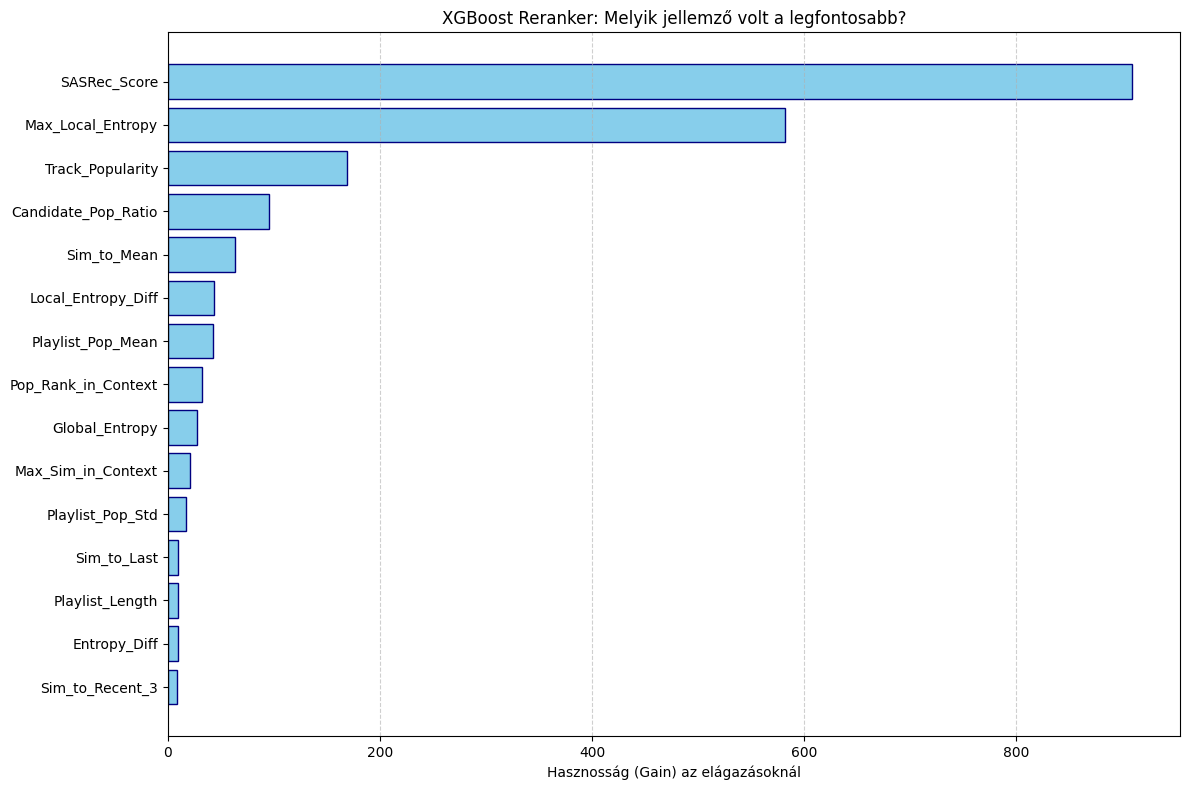


📈 Tanulási görbe...


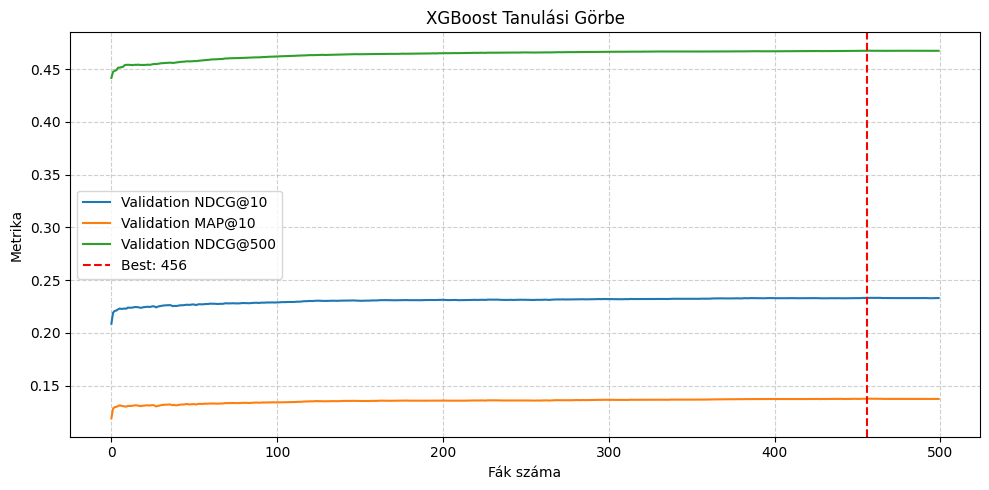

🏆 Legjobb iteráció: 456
🏆 Legjobb NDCG@10: 0.2332


In [1]:
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt

# ==========================================
# 1. ADATBETÖLTÉS ÉS RENDEZÉS
# ==========================================
print("📂 Parquet fájl betöltése...")
df = pd.read_parquet("../Models/xgboost_train_dataset_hybrid_multi_notempo_variable_filtered.parquet")  # ← filtered
df = df.sort_values("Playlist_ID").reset_index(drop=True)

# Listán belüli shuffle — pozitív ne legyen mindig elöl
shuffled_parts = []
for pid, group in df.groupby("Playlist_ID"):
    shuffled_parts.append(group.sample(frac=1, random_state=42))
df = pd.concat(shuffled_parts).reset_index(drop=True)

# ==========================================
# 2. JELLEMZŐK DEFINIÁLÁSA
# ==========================================
features = [
    'Playlist_Length',
    #'SASRec_Rank',
    'SASRec_Score',
    'Sim_to_Last',
    'Sim_to_Mean',
    'Sim_to_Recent_3',       # ← ÚJ
    'Max_Sim_in_Context',    # ← ÚJ
    'Track_Popularity',
    'Global_Entropy',
    'Max_Local_Entropy',
    'Playlist_Pop_Mean',
    'Playlist_Pop_Std',
    'Candidate_Pop_Ratio',
    'Pop_Rank_in_Context',   # ← ÚJ
    'Entropy_Diff',
    'Local_Entropy_Diff'
]

X = df[features]
y = df['Label']
groups = df['Playlist_ID']

# ==========================================
# 3. TRAIN-VAL SPLIT
# ==========================================
total_playlists = groups.max()
train_idx = groups < (total_playlists - 5000)

X_train, y_train, qid_train = X[train_idx], y[train_idx], groups[train_idx]
X_val, y_val, qid_val = X[~train_idx], y[~train_idx], groups[~train_idx]

print(f"✅ Tanító halmaz: {len(X_train):,} sor")
print(f"✅ Validációs halmaz: {len(X_val):,} sor")

# ==========================================
# 4. MODELL DEFINÍCIÓ ÉS TANÍTÁS
# ==========================================
print("\n🚀 XGBoost tanítás indítása...")

ranker = xgb.XGBRanker(
    objective='rank:ndcg',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    tree_method='hist',
    random_state=42,
    eval_metric=['ndcg@10', 'ndcg@500', 'map@10'],
    early_stopping_rounds=200
)

ranker.fit(
    X_train, y_train,
    qid=qid_train,
    eval_set=[(X_val, y_val)],
    eval_qid=[qid_val],
    verbose=50
)

# ==========================================
# 5. MENTÉS ÉS VIZUALIZÁCIÓ
# ==========================================
ranker.save_model("../Models/xgboost_reranker_final_hybrid_multi_notempo_variable.json")
print("\n💾 Modell sikeresen elmentve!")

print("\n📊 Jellemzők fontosságának (Feature Importance) kirajzolása...")
importance = ranker.get_booster().get_score(importance_type='gain')
sorted_importance = sorted(importance.items(), key=lambda x: x[1], reverse=True)
labels, values = zip(*sorted_importance)

plt.figure(figsize=(12, 8))
plt.barh(labels[::-1], values[::-1], color='skyblue', edgecolor='navy')
plt.xlabel("Hasznosság (Gain) az elágazásoknál")
plt.title("XGBoost Reranker: Melyik jellemző volt a legfontosabb?")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\n📈 Tanulási görbe...")
results = ranker.evals_result()
plt.figure(figsize=(10, 5))
plt.plot(results['validation_0']['ndcg@10'], label='Validation NDCG@10')
plt.plot(results['validation_0']['map@10'],  label='Validation MAP@10')
plt.plot(results['validation_0']['ndcg@500'], label='Validation NDCG@500')
plt.axvline(x=ranker.best_iteration, color='red', linestyle='--',
            label=f'Best: {ranker.best_iteration}')
plt.legend()
plt.title('XGBoost Tanulási Görbe')
plt.xlabel('Fák száma')
plt.ylabel('Metrika')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"🏆 Legjobb iteráció: {ranker.best_iteration}")
print(f"🏆 Legjobb NDCG@10: {max(results['validation_0']['ndcg@10']):.4f}")

In [3]:
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
import faiss
import h5py
from gensim.models import Word2Vec
from tqdm.auto import tqdm
import pyarrow as pa
import pyarrow.parquet as pq
import gc

# ==========================================
# 1. ÚTVONALAK ÉS PARAMÉTEREK
# ==========================================
VAL_DATA_PATH   = "../Models/test_pids.npy"
W2V_MODEL_PATH  = "../Models/song2vec.model"
W2V_MATRIX_PATH = "../Models/hybrid_embedding_matrix_notempo.npy"
H5_FILE         = "../Dataset/spotify_dataset_compressed.h5"
WEIGHTS_PATH    = "../Models/best_sasrec_large_hard_w2v_only.weights.h5"
OUTPUT_PARQUET  = "../Models/xgboost_test_dataset_hybrid_multi_notempo_variable.parquet"

MAX_LEN    = 50
BATCH_SIZE = 256
TOP_K      = 1000
MIN_GIVEN  = 1
MAX_GIVEN  = 10

# ==========================================
# 2. METAADATOK ÉS SZÓTÁR ELŐTÖLTÉSE
# ==========================================
print("📖 Word2Vec szótár és beágyazások betöltése...")
w2v_model = Word2Vec.load(W2V_MODEL_PATH)
uri_to_id = w2v_model.wv.key_to_index

embeddings = np.load(W2V_MATRIX_PATH).astype('float32')
vocab_size, D_MODEL = embeddings.shape

embeddings_norm = embeddings.copy()
faiss.normalize_L2(embeddings_norm)

print("📈 Dalok népszerűségének kiszámítása...")
track_popularity = np.zeros(vocab_size, dtype=int)
train_playlists = np.load("../Models/train_pids.npy", allow_pickle=True)
for pl in train_playlists[::10]:  # ← minden 10. lista
    for track_id in pl:
        if track_id < vocab_size:
            track_popularity[track_id] += 1

track_global_entropy = np.full(vocab_size, np.nan, dtype=np.float32)
track_max_local_entropy = np.full(vocab_size, np.nan, dtype=np.float32)
track_is_cnn = np.zeros(vocab_size, dtype=int)

print("🧮 HDF5 metaadatok beolvasása...")
with h5py.File(H5_FILE, "r") as hf:
    track_uris_hdf5 = hf["ml/track_uri"][:]
    entropy_global_data = hf["features/markov_entropy_global"][:]
    entropy_local_data = hf["features/markov_entropy_local"][:]

    if isinstance(track_uris_hdf5[0], bytes):
        track_uris_hdf5 = [uri.decode('utf-8') for uri in track_uris_hdf5]

    for hdf5_idx, uri in enumerate(tqdm(track_uris_hdf5, desc="Mapping")):
        if uri in uri_to_id:
            sasrec_id = uri_to_id[uri]
            if sasrec_id < vocab_size:
                track_global_entropy[sasrec_id] = entropy_global_data[hdf5_idx][0]
                track_max_local_entropy[sasrec_id] = np.max(entropy_local_data[hdf5_idx])
                track_is_cnn[sasrec_id] = 1

print(f"❄️ Cold Start szimulálva: {(track_is_cnn == 1).sum():,} dal népszerűsége lenullázva.")
track_popularity[track_is_cnn == 1] = 0

# ==========================================
# 3. SASREC MODELL (INFERENCIA VERZIÓ)
# ==========================================
print("🏗️ SASRec Modell inicializálása...")
def create_inference_model(vocab_size, init_weights):
    seq_inputs = layers.Input(shape=(MAX_LEN,), name="seq_inputs")
    item_embedding = layers.Embedding(
        vocab_size, D_MODEL, mask_zero=True,
        embeddings_initializer=tf.keras.initializers.Constant(init_weights),
        trainable=True, name="w2v_embedding"
    )
    pos_embedding = layers.Embedding(MAX_LEN, D_MODEL, name="pos_embedding")
    x = item_embedding(seq_inputs)
    x += pos_embedding(tf.range(MAX_LEN)[tf.newaxis, :])
    for _ in range(3):
        attn = layers.MultiHeadAttention(num_heads=8, key_dim=D_MODEL//8)(x, x, use_causal_mask=True)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(attn))
        ffn = layers.Dense(D_MODEL * 4, activation='relu')(x)
        ffn = layers.Dense(D_MODEL)(ffn)
        x = layers.LayerNormalization()(x + layers.Dropout(0.2)(ffn))
    seq_states = layers.Dense(D_MODEL, name="final_projection")(x)
    return tf.keras.Model(inputs=seq_inputs, outputs=seq_states)

inference_model = create_inference_model(vocab_size, embeddings)
inference_model.load_weights(WEIGHTS_PATH)

print("🔍 FAISS Index építése...")
updated_embeddings = inference_model.get_layer("w2v_embedding").get_weights()[0]
faiss_embeddings = updated_embeddings.copy().astype('float32')
faiss.normalize_L2(faiss_embeddings)
index = faiss.IndexFlatIP(D_MODEL)
index.add(faiss_embeddings)

# ==========================================
# 4. KÖTEGELT TÁBLÁZATGENERÁLÁS (VÁLTOZÓ KONTEXTUS)
# ==========================================
print(f"🚀 Táblázat generálása ({MIN_GIVEN}-{MAX_GIVEN} adott dal)...")
val_playlists = np.load(VAL_DATA_PATH, allow_pickle=True)
val_playlists = np.array([[t for t in pl if t != 0] for pl in val_playlists], dtype=object)
val_playlists = val_playlists[::10]  # ← minden 10. playlist
print(f"📋 Felhasznált playlists: {len(val_playlists):,}")

dataset_rows = []
global_playlist_id = 0
writer = None

for i in tqdm(range(0, len(val_playlists), BATCH_SIZE), desc="Feldolgozás"):
    batch_lists = val_playlists[i : i + BATCH_SIZE]

    all_contexts, all_targets = [], []

    for pl in batch_lists:
        if len(pl) <= MIN_GIVEN:
            continue
        for given_n in range(MIN_GIVEN, min(MAX_GIVEN, len(pl) - 1) + 1):
            context = pl[:given_n]
            target_set = set(pl[given_n:])
            all_contexts.append(context)
            all_targets.append(target_set)

    if not all_contexts:
        continue

    batch_padded = []
    for context in all_contexts:
        input_seq = context[-MAX_LEN:]
        batch_padded.append([0] * (MAX_LEN - len(input_seq)) + list(input_seq))

    pred_vectors = inference_model.predict_on_batch(np.array(batch_padded))
    target_pred_vectors = pred_vectors[:, -1, :].astype('float32')
    faiss.normalize_L2(target_pred_vectors)
    raw_scores, raw_indices = index.search(target_pred_vectors, TOP_K + MAX_LEN)

    for b_idx in range(len(all_contexts)):
        context = all_contexts[b_idx]
        actual_targets = all_targets[b_idx]
        num_targets = len(actual_targets)

        last_track_vec = embeddings_norm[context[-1]]
        playlist_mean_vec = np.mean(embeddings_norm[context], axis=0)
        playlist_mean_vec /= (np.linalg.norm(playlist_mean_vec) + 1e-8)

        context_pops = [track_popularity[t] for t in context]
        playlist_pop_mean = float(np.mean(context_pops))
        playlist_pop_std = float(np.std(context_pops))

        context_entropies = [track_global_entropy[t] for t in context
                             if not np.isnan(track_global_entropy[t])]
        playlist_entropy_mean = float(np.mean(context_entropies)) if context_entropies else 0.0

        context_local_entropies = [track_max_local_entropy[t] for t in context
                                   if not np.isnan(track_max_local_entropy[t])]
        playlist_local_entropy_mean = float(np.mean(context_local_entropies)) if context_local_entropies else 0.0

        recent_3 = context[-3:] if len(context) >= 3 else context
        recent_3_vecs = embeddings_norm[recent_3]
        context_pops_arr = np.array(context_pops)
        context_vecs = embeddings_norm[list(context)]

        pos_samples, neg_samples = [], []
        current_rank = 1

        for score, cand_id in zip(raw_scores[b_idx], raw_indices[b_idx]):
            if cand_id in context or cand_id == 0:
                continue
            if len(pos_samples) + len(neg_samples) >= TOP_K:
                break

            is_target = 1 if cand_id in actual_targets else 0
            cand_vec = embeddings_norm[cand_id]
            cand_pop = track_popularity[cand_id]
            cand_entropy = track_global_entropy[cand_id]
            cand_local_entropy = track_max_local_entropy[cand_id]

            pop_ratio = cand_pop / (playlist_pop_mean + 1.0)
            entropy_diff = abs(cand_entropy - playlist_entropy_mean) if not np.isnan(cand_entropy) else -1.0
            local_entropy_diff = abs(cand_local_entropy - playlist_local_entropy_mean) if not np.isnan(cand_local_entropy) else -1.0
            sim_to_recent_3 = float(np.mean(recent_3_vecs @ cand_vec))
            max_sim_in_context = float(np.max(context_vecs @ cand_vec))
            pop_rank_in_context = float(np.mean(context_pops_arr > cand_pop))

            row = {
                "Playlist_ID":         global_playlist_id,
                "Candidate_ID":        cand_id,
                "Playlist_Length":     len(context),
                "Num_Targets":         num_targets,
                "SASRec_Rank":         current_rank,
                "SASRec_Score":        float(score),
                "Sim_to_Last":         float(np.dot(last_track_vec, cand_vec)),
                "Sim_to_Mean":         float(np.dot(playlist_mean_vec, cand_vec)),
                "Sim_to_Recent_3":     sim_to_recent_3,
                "Max_Sim_in_Context":  max_sim_in_context,
                "Track_Popularity":    cand_pop,
                "Global_Entropy":      cand_entropy,
                "Max_Local_Entropy":   cand_local_entropy,
                "Playlist_Pop_Mean":   playlist_pop_mean,
                "Playlist_Pop_Std":    playlist_pop_std,
                "Candidate_Pop_Ratio": float(pop_ratio),
                "Pop_Rank_in_Context": pop_rank_in_context,
                "Entropy_Diff":        float(entropy_diff),
                "Local_Entropy_Diff":  float(local_entropy_diff),
                "Label":               is_target
            }

            if is_target:
                pos_samples.append(row)
            else:
                neg_samples.append(row)
            current_rank += 1

        dataset_rows.extend(pos_samples)
        dataset_rows.extend(neg_samples)
        global_playlist_id += 1

    if len(dataset_rows) >= 500_000:
        df_chunk = pd.DataFrame(dataset_rows)
        table = pa.Table.from_pandas(df_chunk)
        if writer is None:
            writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
        writer.write_table(table)
        dataset_rows.clear()
        del df_chunk, table
        gc.collect()

# ==========================================
# 5. MARADÉK KIÍRÁSA ÉS FÁJL LEZÁRÁSA
# ==========================================
print("💾 Maradék adatok mentése és fájl lezárása...")
if len(dataset_rows) > 0:
    df_chunk = pd.DataFrame(dataset_rows)
    table = pa.Table.from_pandas(df_chunk)
    if writer is None:
        writer = pq.ParquetWriter(OUTPUT_PARQUET, table.schema)
    writer.write_table(table)

if writer is not None:
    writer.close()

# ==========================================
# 6. SZŰRÉS
# ==========================================
print("🧹 Pozitív nélküli listák szűrése...")
df = pd.read_parquet(OUTPUT_PARQUET)
lists_with_pos = df[df['Label'] == 1]['Playlist_ID'].unique()
df_filtered = df[df['Playlist_ID'].isin(lists_with_pos)].reset_index(drop=True)
df_filtered.to_parquet(OUTPUT_PARQUET.replace('.parquet', '_filtered.parquet'), index=False)

print(f"🎉 KÉSZ! Generált sorok: {len(df):,} → Szűrt sorok: {len(df_filtered):,}")
del df, df_filtered
gc.collect()

📖 Word2Vec szótár és beágyazások betöltése...
📈 Dalok népszerűségének kiszámítása...
🧮 HDF5 metaadatok beolvasása...


Mapping:   0%|          | 0/27052 [00:00<?, ?it/s]

❄️ Cold Start szimulálva: 25,511 dal népszerűsége lenullázva.
🏗️ SASRec Modell inicializálása...
🔍 FAISS Index építése...
🚀 Táblázat generálása (1-10 adott dal)...
📋 Felhasznált playlists: 9,918


Feldolgozás:   0%|          | 0/39 [00:00<?, ?it/s]

💾 Maradék adatok mentése és fájl lezárása...
🧹 Pozitív nélküli listák szűrése...


ArrowMemoryError: malloc of size 5453504000 failed

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb

# ==========================================
# 1. ADATOK ÉS MODELL BETÖLTÉSE
# ==========================================
df_test = pd.read_parquet("../Models/xgboost_test_dataset_hybrid_multi_notempo_variable.parquet")

features = [
    'Playlist_Length', 'SASRec_Score', 'Sim_to_Last', 'Sim_to_Mean',
    'Sim_to_Recent_3', 'Max_Sim_in_Context', 'Track_Popularity',
    'Global_Entropy', 'Max_Local_Entropy', 'Playlist_Pop_Mean',
    'Playlist_Pop_Std', 'Candidate_Pop_Ratio', 'Pop_Rank_in_Context',
    'Entropy_Diff', 'Local_Entropy_Diff'
]

ranker = xgb.XGBRanker()
ranker.load_model("../Models/xgboost_reranker_final_hybrid_multi_notempo_variable.json") 

df_test['XGB_Score'] = ranker.predict(df_test[features])

df_test['XGB_Rank'] = df_test.groupby('Playlist_ID')['XGB_Score'].rank(
    ascending=False, method='first'
).astype(int)

# ==========================================
# 2. ÚJ MULTI-TARGET KIÉRTÉKELŐ FÜGGVÉNY
# ==========================================
def calculate_metrics_multi(df, rank_col, k_list, default_num_targets=25):
    results = {k: {'Recall': 0.0, 'NDCG': 0.0} for k in k_list}
    total_clicks = 0
    total_r_prec = 0.0
    
    grouped = df.groupby('Playlist_ID')
    total_queries = len(grouped)
    
    if total_queries == 0:
        return pd.DataFrame(), 0, 0
    
    for pid, group in grouped:
        if 'Num_Targets' in group.columns:
            num_targets = group['Num_Targets'].iloc[0]
        else:
            num_targets = default_num_targets
            
        hits = group[group['Label'] == 1]
        hit_ranks = hits[rank_col].values.tolist()
        hit_ranks.sort() 
        
        if len(hit_ranks) > 0:
            first_hit = hit_ranks[0]
            if first_hit <= 500:
                clicks = (first_hit - 1) // 10
            else:
                clicks = 51
        else:
            clicks = 51
        total_clicks += clicks
        
        hits_in_r = sum(1 for r in hit_ranks if r <= num_targets)
        total_r_prec += (hits_in_r / num_targets) if num_targets > 0 else 0
        
        for k in k_list:
            k_hits = [r for r in hit_ranks if r <= k]
            if num_targets > 0:
                results[k]['Recall'] += len(k_hits) / num_targets
                dcg = sum(1.0 / np.log2(r + 1) for r in k_hits)
                idcg_len = min(k, num_targets)
                idcg = sum(1.0 / np.log2(pos + 1) for pos in range(1, idcg_len + 1))
                if idcg > 0:
                    results[k]['NDCG'] += (dcg / idcg)

    final_results = []
    for k in k_list:
        final_results.append({
            'k': k, 
            'Recall': results[k]['Recall'] / total_queries, 
            'NDCG': results[k]['NDCG'] / total_queries
        })
        
    avg_clicks = total_clicks / total_queries
    avg_r_prec = total_r_prec / total_queries
    
    return pd.DataFrame(final_results), avg_clicks, avg_r_prec

# ==========================================
# 3. KIÉRTÉKELÉS KÜLÖN SEED MÉRETEKRE (1-10)
# ==========================================
K_VALUES = [1, 5, 10, 20, 50, 100, 200, 500]

# Lekérjük a teszthalmazban lévő összes létező seed hosszt (1, 2, ... 10)
seed_lengths = sorted(df_test['Playlist_Length'].unique())

for seed_len in seed_lengths:
    # Leszűrjük csak az aktuális seed méretre
    df_subset = df_test[df_test['Playlist_Length'] == seed_len]
    
    print("\n" + "━"*70)
    print(f"🎯 EREDMÉNYEK: {seed_len} MEGADOTT DAL (SEED) ESETÉN")
    print("━"*70)
    
    sas_m, sas_c, sas_r = calculate_metrics_multi(df_subset, 'SASRec_Rank', K_VALUES)
    xgb_m, xgb_c, xgb_r = calculate_metrics_multi(df_subset, 'XGB_Rank', K_VALUES)

    summary = sas_m.set_index('k').join(xgb_m.set_index('k'), lsuffix='_SAS', rsuffix='_XGB')

    for m in ['Recall', 'NDCG']:
        summary[f'{m}_imp%'] = (summary[f'{m}_XGB'] - summary[f'{m}_SAS']) / summary[f'{m}_SAS'] * 100

    pd.options.display.float_format = '{:.4f}'.format
    cols = [c for m in ['Recall','NDCG'] for c in [f'{m}_SAS', f'{m}_XGB', f'{m}_imp%']]
    print(summary[cols].T.to_string())

    print(f"\n🎯 R-Precision SASRec:  {sas_r:.4f}")
    print(f"🎯 R-Precision XGBoost: {xgb_r:.4f}")
    if sas_r > 0:
        print(f"🚀 R-Precision javulás: {(xgb_r - sas_r)/sas_r*100:.2f}%\n")

    print(f"🖱️ Clicks SASRec:  {sas_c:.4f}")
    print(f"🖱️ Clicks XGBoost: {xgb_c:.4f}")
    if sas_c > 0:
        print(f"🚀 Clicks javulás: {(xgb_c - sas_c)/sas_c*100:.2f}%")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🎯 EREDMÉNYEK: 1 MEGADOTT DAL (SEED) ESETÉN
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
k              1      5      10      20      50      100     200     500
Recall_SAS  0.0063 0.0240 0.0404  0.0635  0.1076  0.1522  0.2060  0.2935
Recall_XGB  0.0067 0.0261 0.0440  0.0704  0.1210  0.1745  0.2423  0.3386
Recall_imp% 5.3600 8.4160 8.9284 10.9957 12.5312 14.6752 17.6045 15.3649
NDCG_SAS    0.2510 0.2071 0.1855  0.1622  0.1449  0.1507  0.1712  0.2101
NDCG_XGB    0.2613 0.2242 0.2024  0.1792  0.1623  0.1710  0.1979  0.2411
NDCG_imp%   4.1382 8.2368 9.0908 10.4435 12.0122 13.4548 15.5784 14.7629

🎯 R-Precision SASRec:  0.0960
🎯 R-Precision XGBoost: 0.1107
🚀 R-Precision javulás: 15.34%

🖱️ Clicks SASRec:  6.2354
🖱️ Clicks XGBoost: 4.4598
🚀 Clicks javulás: -28.48%

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🎯 EREDMÉNYEK: 2 MEGADOTT DAL (SEED) ESETÉN
━━━━━━━━━━━━━━━━━━